In [1]:
import pandas as pd

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(X_train.shape, X_test.shape)
X_train.columns.tolist()

(5634, 30) (1409, 30)


['SeniorCitizen',
 'tenure',
 'MonthlyCharges',
 'TotalCharges',
 'gender_Male',
 'Partner_Yes',
 'Dependents_Yes',
 'PhoneService_Yes',
 'MultipleLines_No phone service',
 'MultipleLines_Yes',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_No internet service',
 'OnlineSecurity_Yes',
 'OnlineBackup_No internet service',
 'OnlineBackup_Yes',
 'DeviceProtection_No internet service',
 'DeviceProtection_Yes',
 'TechSupport_No internet service',
 'TechSupport_Yes',
 'StreamingTV_No internet service',
 'StreamingTV_Yes',
 'StreamingMovies_No internet service',
 'StreamingMovies_Yes',
 'Contract_One year',
 'Contract_Two year',
 'PaperlessBilling_Yes',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

In [2]:
X_train['AvgMonthlySpend'] = X_train['TotalCharges'] / (X_train['tenure'] + 1)
X_test['AvgMonthlySpend'] = X_test['TotalCharges'] / (X_test['tenure'] + 1)

X_train[['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend']].head()

,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend
0,0.102371,-0.521976,-0.262257,-0.237903
1,-0.711743,0.337478,-0.503635,-1.747176
2,-0.793155,-0.809013,-0.749883,-3.625336
3,-0.263980,0.284384,-0.172722,-0.234671
4,-1.281624,-0.676279,-0.989374,3.513105


In [3]:
# Reload the original cleaned (but unscaled) data from Phase 3, before scaling was applied
df_raw = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_raw['TotalCharges'] = pd.to_numeric(df_raw['TotalCharges'], errors='coerce').fillna(0)

# Recompute using true tenure/TotalCharges values (not scaled)
avg_monthly_spend_train = df_raw.loc[y_train.index, 'TotalCharges'] / (df_raw.loc[y_train.index, 'tenure'] + 1)
avg_monthly_spend_test = df_raw.loc[y_test.index, 'TotalCharges'] / (df_raw.loc[y_test.index, 'tenure'] + 1)

X_train['AvgMonthlySpend'] = avg_monthly_spend_train.values
X_test['AvgMonthlySpend'] = avg_monthly_spend_test.values

X_train[['AvgMonthlySpend']].describe()

,AvgMonthlySpend
count,5634.000000
mean,59.097567
std,30.598002
min,0.000000
25%,25.992551
50%,61.340944
75%,84.889167
max,118.969863


In [4]:
tenure_train = df_raw.loc[y_train.index, 'tenure']
tenure_test = df_raw.loc[y_test.index, 'tenure']

bins = [-1, 12, 24, 48, 100]
labels = ['0-12mo', '13-24mo', '25-48mo', '49mo+']

tenure_group_train = pd.cut(tenure_train, bins=bins, labels=labels)
tenure_group_test = pd.cut(tenure_test, bins=bins, labels=labels)

# One-hot encode the new bins and attach to X_train/X_test
tenure_dummies_train = pd.get_dummies(tenure_group_train, prefix='TenureGroup', drop_first=True)
tenure_dummies_test = pd.get_dummies(tenure_group_test, prefix='TenureGroup', drop_first=True)

X_train = pd.concat([X_train.reset_index(drop=True), tenure_dummies_train.reset_index(drop=True)], axis=1)
X_test = pd.concat([X_test.reset_index(drop=True), tenure_dummies_test.reset_index(drop=True)], axis=1)

print(X_train.shape, X_test.shape)
X_train.filter(like='TenureGroup').head()

(5634, 34) (1409, 34)


,TenureGroup_13-24mo,TenureGroup_25-48mo,TenureGroup_49mo+
0,False,False,False
1,False,True,False
2,False,False,False
3,False,True,False
4,False,False,False


In [5]:
service_cols = [
    'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes',
    'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes'
]

X_train['NumServices'] = X_train[service_cols].sum(axis=1)
X_test['NumServices'] = X_test[service_cols].sum(axis=1)

X_train['NumServices'].value_counts().sort_index()

NumServices
0    1757
1     766
2     832
3     885
4     695
5     464
6     235
Name: count, dtype: int64

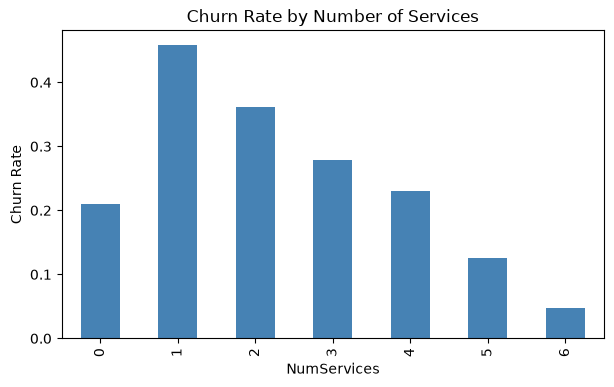

In [6]:
import matplotlib.pyplot as plt

churn_by_services = pd.DataFrame({
    'NumServices': X_train['NumServices'],
    'Churn': y_train
}).groupby('NumServices')['Churn'].mean()

churn_by_services.plot(kind='bar', color='steelblue', figsize=(7,4))
plt.title('Churn Rate by Number of Services')
plt.ylabel('Churn Rate')
plt.show()

In [7]:
X_train.to_csv('../data/processed/X_train_fe.csv', index=False)
X_test.to_csv('../data/processed/X_test_fe.csv', index=False)
print("Saved feature-engineered data:", X_train.shape, X_test.shape)

Saved feature-engineered data: (5634, 35) (1409, 35)
